# Animal Classification — ResNet50 + Quantization (TensorFlow)

In [1]:
import os, shutil, uuid, time, pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("TF version:", tf.__version__)

TF version: 2.20.0


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"rambhadrakumar","key":"3802cabd2ec9aec83dabcac171bc5da6"}'}

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
os.system('kaggle datasets download -d alessiocorrado99/animals10 --unzip -p /content/animals10')

0

In [4]:
DATA_DIR = '/content/animals10/raw-img'

rename_map = {
    'cane': 'dog', 'cavallo': 'horse', 'elefante': 'elephant',
    'farfalla': 'butterfly', 'gallina': 'chicken', 'gatto': 'cat',
    'mucca': 'cow', 'pecora': 'sheep', 'ragno': 'spider', 'scoiattolo': 'squirrel'
}

for italian, english in rename_map.items():
    old_path = os.path.join(DATA_DIR, italian)
    new_path = os.path.join(DATA_DIR, english)
    if os.path.exists(old_path) and os.path.exists(new_path):
        for file in os.listdir(old_path):
            src = os.path.join(old_path, file)
            dst = os.path.join(new_path, file)
            if os.path.exists(dst):
                name, ext = os.path.splitext(file)
                dst = os.path.join(new_path, f"{name}_{uuid.uuid4().hex[:6]}{ext}")
            shutil.move(src, dst)
        os.rmdir(old_path)
        print(f"Merged: {italian} -> {english}")
    elif os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed: {italian} -> {english}")

print("\nFinal folders:", sorted(os.listdir(DATA_DIR)))

Merged: cane -> dog
Merged: cavallo -> horse
Merged: elefante -> elephant
Merged: farfalla -> butterfly
Merged: gallina -> chicken
Merged: gatto -> cat
Merged: mucca -> cow
Merged: pecora -> sheep
Merged: ragno -> spider
Merged: scoiattolo -> squirrel

Final folders: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [5]:
SELECTED_CLASSES = ['dog', 'cat', 'horse', 'elephant', 'butterfly']
NUM_CLASSES      = len(SELECTED_CLASSES)
IMG_SIZE         = 224
BATCH_SIZE       = 16
EPOCHS_P1        = 10
EPOCHS_P2        = 10
SAMPLES_TRAIN    = 800
SAMPLES_VAL      = 200
AUTOTUNE         = tf.data.AUTOTUNE
SUBSET_DIR       = '/content/animals_subset'

In [6]:
if os.path.exists(SUBSET_DIR):
    shutil.rmtree(SUBSET_DIR)
os.makedirs(SUBSET_DIR)

for cls in SELECTED_CLASSES:
    src = os.path.join(DATA_DIR, cls)
    dst = os.path.join(SUBSET_DIR, cls)
    os.makedirs(dst, exist_ok=True)
    all_files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected  = all_files[:SAMPLES_TRAIN + SAMPLES_VAL]
    for f in selected:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    print(f"{cls}: {len(selected)} images copied")

print("\nSubset ready!")

dog: 1000 images copied
cat: 1000 images copied
horse: 1000 images copied
elephant: 1000 images copied
butterfly: 1000 images copied

Subset ready!


In [7]:
train_ds = image_dataset_from_directory(
    SUBSET_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    SUBSET_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches  :", len(val_ds))

Found 5000 files belonging to 5 classes.
Using 4000 files for training.
Found 5000 files belonging to 5 classes.
Using 1000 files for validation.
Classes: ['butterfly', 'cat', 'dog', 'elephant', 'horse']
Train batches: 250
Val batches  : 63


In [8]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(AUTOTUNE)

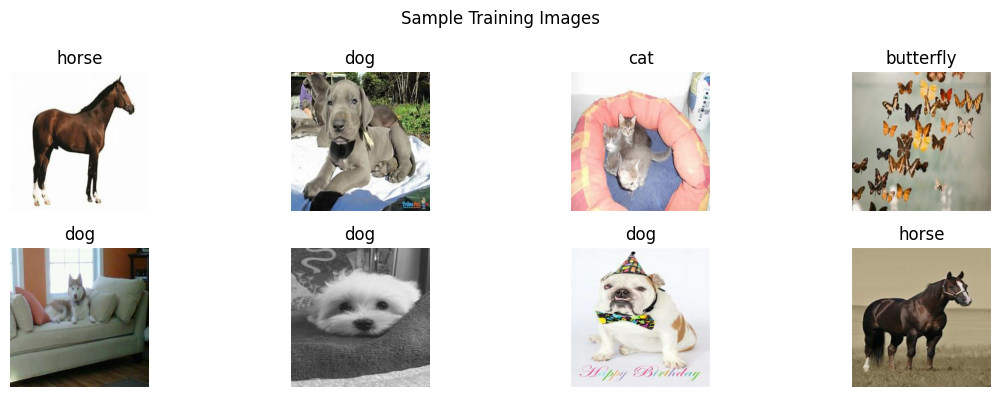

In [9]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
])

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,733 (92.02 MB)

 Trainable params: 529,925 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 128ms/step - accuracy: 0.4703 - loss: 1.8300 - val_accuracy: 0.2990 - val_loss: 25.8770
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 121ms/step - accuracy: 0.5500 - loss: 1.1288 - val_accuracy: 0.3930 - val_loss: 1.7717
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - accuracy: 0.5840 - loss: 1.0566 - val_accuracy: 0.3970 - val_loss: 3.7943
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 120ms/step - accuracy: 0.6058 - loss: 0.9994 - val_accuracy: 0.4890 - val_loss: 7.0956
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - accuracy: 0.6080 - loss: 0.9867 - val_accuracy: 0.3180 - val_loss: 21.1894
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - accuracy: 0.6150 - loss: 0.9535 - val_accuracy: 0.2810 - val_loss: 5.8049
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - accuracy: 0.6342 - loss: 0.9434 - val_accuracy: 0.3380 - val_loss: 18.0021
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - accuracy: 0.6417 - loss

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - accuracy: 0.6730 - loss: 0.8394 - val_accuracy: 0.6180 - val_loss: 0.9699 - learning_rate: 1.0000e-05
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - accuracy: 0.6800 - loss: 0.8161 - val_accuracy: 0.6590 - val_loss: 0.9494 - learning_rate: 1.0000e-05
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.6825 - loss: 0.8013 - val_accuracy: 0.6820 - val_loss: 0.8778 - learning_rate: 1.0000e-05
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.6898 - loss: 0.7857 - val_accuracy: 0.6870 - val_loss: 0.8292 - learning_rate: 1.0000e-05
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.6965 - loss: 0.7686 - val_accuracy: 0.7060 - val_loss: 0.7766 - learning_rate: 1.0000e-05
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.6980 - loss: 0.7605 - val_accuracy: 0.6970 - val_loss: 0.7950 - learning_rate: 1.0000e-05
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 10

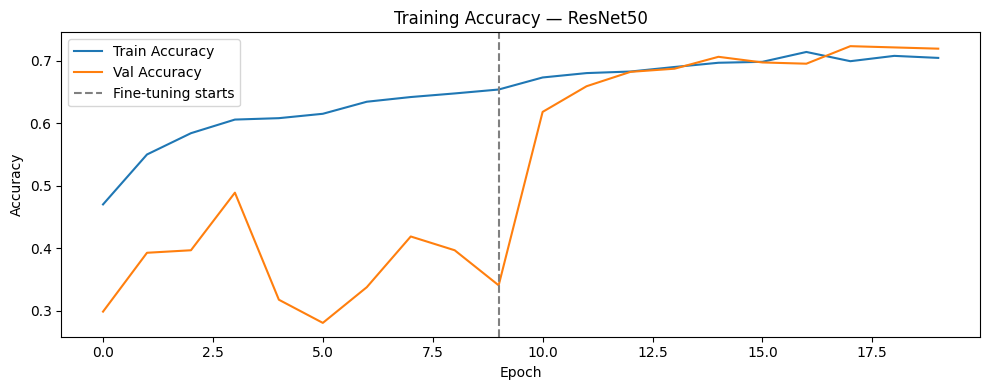

In [15]:
all_acc  = history1.history['accuracy']  + history2.history['accuracy']
all_vacc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(all_acc,  label='Train Accuracy')
plt.plot(all_vacc, label='Val Accuracy')
plt.axvline(x=EPOCHS_P1 - 1, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Accuracy — ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
orig_loss, orig_acc = model.evaluate(val_ds)
print(f"Original Model — Loss: {orig_loss:.4f}  Accuracy: {orig_acc*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.7230 - loss: 0.7632
Original Model — Loss: 0.7632  Accuracy: 72.30%


In [17]:
model.save('animal_resnet50.keras')
orig_size = os.path.getsize('animal_resnet50.keras') / (1024 * 1024)
print(f"Original Model Size: {orig_size:.2f} MB")

Original Model Size: 164.86 MB


In [23]:
interpreter = tf.lite.Interpreter(model_path='animal_resnet50_quantized.tflite', num_threads=4)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def evaluate_tflite(interp, dataset):
    correct = 0
    total   = 0
    start   = time.time()
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            img_input = np.expand_dims(img, axis=0).astype(np.float32)
            interp.set_tensor(input_details[0]['index'], img_input)
            interp.invoke()
            output  = interp.get_tensor(output_details[0]['index'])
            pred    = np.argmax(output)
            correct += int(pred == label)
            total   += 1
    elapsed = time.time() - start
    return (correct / total) * 100, elapsed

quant_acc, quant_time = evaluate_tflite(interpreter, val_ds)
print(f"Quantized — Accuracy: {quant_acc:.2f}%  |  Inference Time: {quant_time:.2f}s")

Quantized — Accuracy: 35.00%  |  Inference Time: 133.97s


In [24]:
def representative_dataset():
    for images, _ in train_ds.take(100):
        for img in images:
            yield [tf.expand_dims(img, 0)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open('animal_resnet50_quantized.tflite', 'wb') as f:
    f.write(tflite_model)

quant_size = os.path.getsize('animal_resnet50_quantized.tflite') / (1024 * 1024)
print(f"Quantized Model Size: {quant_size:.2f} MB")
print(f"Size Reduction      : {((orig_size - quant_size) / orig_size) * 100:.1f}%")

Saved artifact at '/tmp/tmpuoh6mqee'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_175')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134026804954128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804954512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804955664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804956624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804956432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804955856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804958736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804959120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804961040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134026804961232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1340268049

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


KeyboardInterrupt: 

## 16. Comparison

In [25]:
start = time.time()
model.evaluate(val_ds, verbose=0)
orig_time = time.time() - start

print(f"Original  — Size: {orig_size:.2f} MB  |  Accuracy: {orig_acc*100:.2f}%  |  Time: {orig_time:.2f}s")
print(f"Quantized — Size: {quant_size:.2f} MB  |  Accuracy: {quant_acc:.2f}%  |  Time: {quant_time:.2f}s")

Original  — Size: 164.86 MB  |  Accuracy: 72.30%  |  Time: 4.86s
Quantized — Size: 23.32 MB  |  Accuracy: 35.00%  |  Time: 133.97s


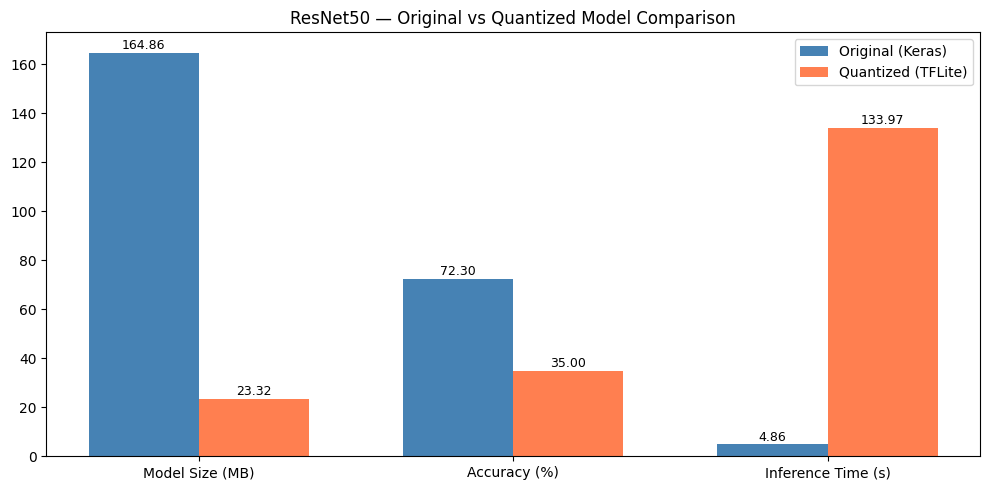

In [26]:
categories = ['Model Size (MB)', 'Accuracy (%)', 'Inference Time (s)']
orig_vals  = [orig_size, orig_acc * 100, orig_time]
quant_vals = [quant_size, quant_acc, quant_time]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, orig_vals,  width, label='Original (Keras)',   color='steelblue')
bars2 = ax.bar(x + width/2, quant_vals, width, label='Quantized (TFLite)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('ResNet50 — Original vs Quantized Model Comparison')
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 17. Confusion Matrix

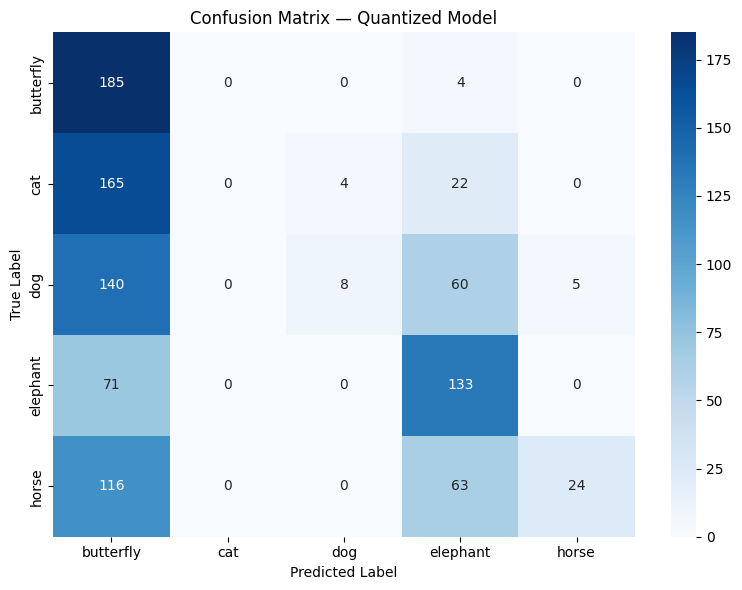

              precision    recall  f1-score   support

   butterfly       0.27      0.98      0.43       189
         cat       0.00      0.00      0.00       191
         dog       0.67      0.04      0.07       213
    elephant       0.47      0.65      0.55       204
       horse       0.83      0.12      0.21       203

    accuracy                           0.35      1000
   macro avg       0.45      0.36      0.25      1000
weighted avg       0.46      0.35      0.25      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
all_preds  = []
all_labels = []

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])
        all_preds.append(np.argmax(output))
        all_labels.append(label)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix — Quantized Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 18. Download Models

In [29]:
from google.colab import files
files.download('animal_resnet50.keras')
files.download('animal_resnet50_quantized.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>